In [27]:
# autoreload
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd
sys.path.append('../')
from src.ageModel import SigmaAgeModel
from src.utilities import physical_to_nondim

# illustrative example of nondimensionalization
physical_to_nondim(
    u_surface_myr = 1.0,   # 100 m/yr surface velocity
    H_m           = 1000.0,  # 1 km thick
    a_myr         = -0.5,     # 0.5 m/yr melting (negative = ablation)
    L_m           = 20e3,   # 20 km domain
    w_basal_myr   = 1,    # 1 m/yr freeze-on
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

──────────────────────────────────────────────────────
  Physical → Nondimensional Parameter Translation
──────────────────────────────────────────────────────
  INPUT PHYSICAL QUANTITIES
    Surface velocity   u_s  =       1.00  m yr⁻¹
    Ice thickness      H    =    1000.00  m
    Accumulation rate  a    =    -0.5000  m yr⁻¹
    Domain length      L    =   20000.00  m
    Basal velocity     w_b  =     1.0000  m yr⁻¹

  CHARACTERISTIC SCALES
    Time scale   H/a        =     2000.0  yr
    Horiz. vel. scale L·a/H =      10.00  m yr⁻¹
    Vert.  vel. scale  a/H  =   0.000500  yr⁻¹  (-0.5000 × 10⁻³ yr⁻¹)

  NONDIMENSIONAL PARAMETERS
    Flush   = u_s / (L·a/H) =    0.100
    W_basal = w_b / a       =    2.000

  INTERPRETATION
    1 nondim time unit      = 2000.0 yr
    X_tilde = 1  means age  = 2000.0 yr
    X_tilde = 0.1  means age  = 200.0 yr  (≈ transit time)
    W_basal = 2.000  means basal fr

{'Flush': 0.1,
 'W_basal': 2.0,
 't_scale_yr': 2000.0,
 'X_scale_yr': 2000.0,
 'L_m': 20000.0,
 'residence_time_yr': 2000.0}


  CASE 1 — no basal perturbation
  Baseline CFL dt_macro = 0.00404  (u_max=0.100, w_max=1.0000)
  Running 1980 macro-steps  (t_total=8.0 residence times, perturbation=OFF)
    macro      0/1980  t=0.000  w_basal=0.000  sub-steps=1  dt_micro=0.004040  max(X)=0.004  mean(X)=0.004
    macro    247/1980  t=0.998  w_basal=0.000  sub-steps=1  dt_micro=0.004040  max(X)=1.002  mean(X)=0.608
    macro    494/1980  t=1.996  w_basal=0.000  sub-steps=1  dt_micro=0.004040  max(X)=2.000  mean(X)=0.823
    macro    741/1980  t=2.994  w_basal=0.000  sub-steps=1  dt_micro=0.004040  max(X)=2.998  mean(X)=0.905
    macro    988/1980  t=3.992  w_basal=0.000  sub-steps=1  dt_micro=0.004040  max(X)=3.996  mean(X)=0.941
    macro   1235/1980  t=4.990  w_basal=0.000  sub-steps=1  dt_micro=0.004040  max(X)=4.994  mean(X)=0.961
    macro   1482/1980  t=5.988  w_basal=0.000  sub-steps=1  dt_micro=0.004040  max(X)=5.992  mean(X)=0.974
    macro   1729/1980  t=6.986  w_basal=0.000  sub-steps=1  dt_micro=0.004040 

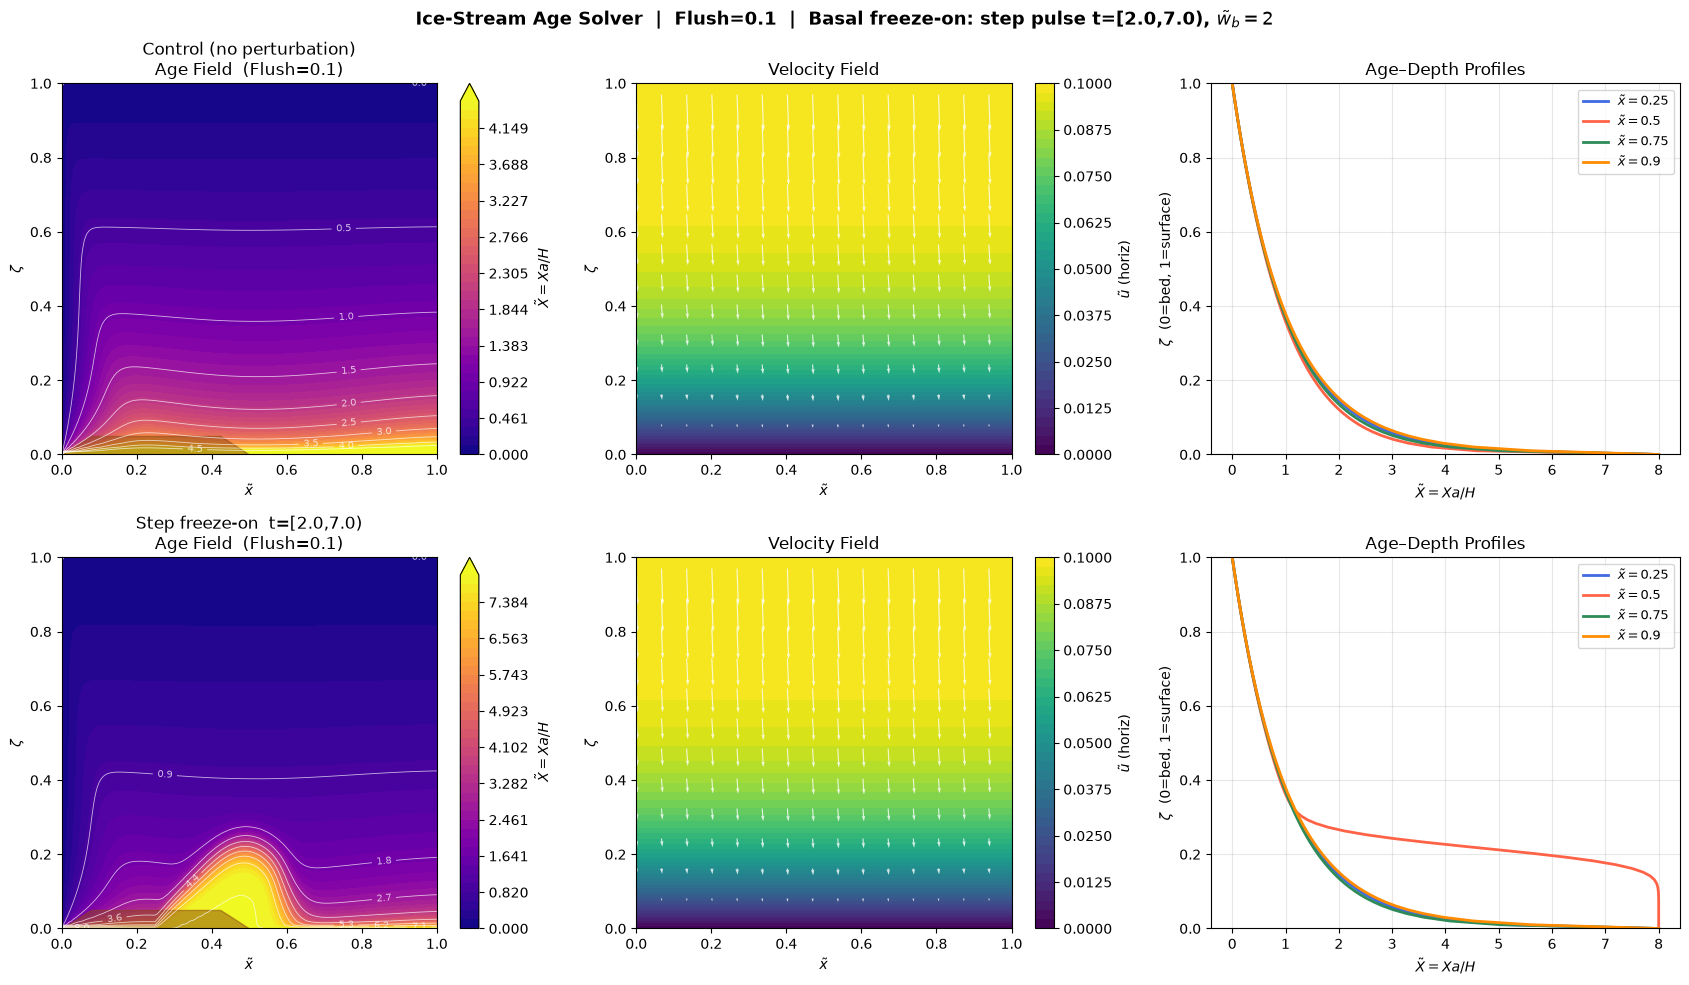

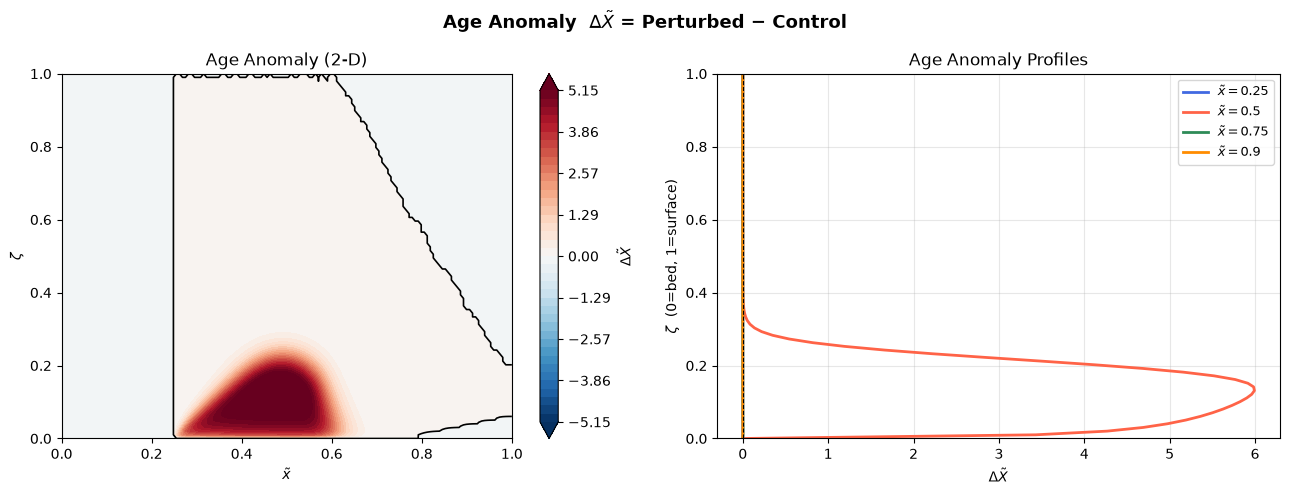

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Basal freeze-on perturbation definition
# ─────────────────────────────────────────────────────────────────────────────
# Nondim time window for the step perturbation.
# The model runs for n_residence_times=16 total; freeze-on is active t=[2, 8].
T_ON  = 2.0   # switch ON  at this nondim time
T_OFF = 7.0   # switch OFF at this nondim time
N_RES  = 8    # total residence times to integrate
PERT_XLIM = [0.25, 0.5]
FLUSH = 0.1   # nondim surface velocity scale (u_s / (L·a/H))
SNAPSHOT_INTERVAL = 100  # save snapshots every this many timesteps
W_FREEZE = 2  # magnitude of basal upward velocity (nondim, positive = up)

def no_perturbation(t):
    """Always zero — baseline control run."""
    return 0.0

def step_perturbation(t):
    """
    Rectangular pulse: freeze-on active between T_ON and T_OFF.
    Returns a uniform (scalar) w_basal across all x.
    """
    return W_FREEZE if T_ON <= t < T_OFF else 0.0

def localized_freeze_on_step(t):
    wb = np.zeros(150)
    if T_ON <= t < T_OFF:
        # Freeze-on active only in x = [0.3, 0.7]
        x = np.linspace(0, 1, 150)
        mask = (x >= PERT_XLIM[0]) & (x <= PERT_XLIM[1])
        wb[mask] = W_FREEZE
    return wb

def localized_freeze_on_gaussian(t):
    wb = np.zeros(150)
    if T_ON <= t < T_OFF:
        # Freeze-on active
        x = np.linspace(0, 1, 150)
        mask = (x >= PERT_XLIM[0]) & (x <= PERT_XLIM[1])
        wb[mask] = W_FREEZE * np.exp(-((x[mask]-(PERT_XLIM[0]+PERT_XLIM[1])/2.0)/0.1)**2)
    return wb

def localized_freeze_on_smooth(
    t,
    nx          = 150,
    x_center    = (PERT_XLIM[0] + PERT_XLIM[1]) / 2.0,
    x_sigma     = 0.1,
    x_lo        = PERT_XLIM[0],
    x_hi        = PERT_XLIM[1],
    t_to_peak   = 0.1,    # nondim time to ramp from 0 → W_FREEZE after T_ON
    t_to_zero   = 0.1,    # nondim time to ramp from W_FREEZE → 0 after T_OFF
):
    """
    Spatially Gaussian, temporally smooth basal freeze-on perturbation.

    Spatial shape
    -------------
    Gaussian centred at x_center with std x_sigma, masked to [x_lo, x_hi].
    Peak amplitude = W_FREEZE.

    Temporal shape
    --------------
    Uses a smooth C-infinity ramp (based on the standard bump function)
    rather than a hard step, so:
      - ramps from 0 → W_FREEZE over [T_ON,        T_ON  + t_to_peak]
      - holds at W_FREEZE         over [T_ON+t_to_peak, T_OFF]
      - ramps from W_FREEZE → 0  over [T_OFF,       T_OFF + t_to_zero]
      - zero outside that window

    Parameters
    ----------
    t           : float  — current nondim time
    nx          : int    — number of x grid points (must match model)
    x_center    : float  — Gaussian centre in nondim x
    x_sigma     : float  — Gaussian std in nondim x
    x_lo, x_hi  : float  — hard mask: Gaussian is zeroed outside this window
    t_to_peak   : float  — nondim ramp-up duration after T_ON
    t_to_zero   : float  — nondim ramp-down duration after T_OFF

    Returns
    -------
    wb : ndarray (nx,)  — nondim basal upward velocity at each x
    """

    # ── Smooth ramp kernel: maps s ∈ [0,1] → [0,1] via bump function ─────────
    # Uses the C∞ sigmoid  φ(s) = 1 / (1 + exp(1/(s-1) - 1/s))
    # which is exactly 0 at s≤0, exactly 1 at s≥1, and infinitely smooth.
    def smooth_ramp(s):
        """Vectorisable C∞ ramp: 0→1 over s ∈ [0,1]."""
        s   = np.asarray(s, dtype=float)
        out = np.zeros_like(s)
        interior = (s > 0.0) & (s < 1.0)
        si = s[interior]
        # Numerically safe: clamp exponent argument
        exp_arg = np.clip(1.0 / (si - 1.0) - 1.0 / si, -500, 500)
        out[interior] = 1.0 / (1.0 + np.exp(exp_arg))
        out[s >= 1.0] = 1.0
        return out

    # ── Temporal amplitude ────────────────────────────────────────────────────
    if t < T_ON or t >= T_OFF + t_to_zero:
        return np.zeros(nx)

    if t < T_ON + t_to_peak:
        # Ramp up: s goes 0→1 as t goes T_ON → T_ON+t_to_peak
        s         = (t - T_ON) / t_to_peak
        amplitude = smooth_ramp(np.array([s]))[0]

    elif t < T_OFF:
        # Plateau
        amplitude = 1.0

    else:
        # Ramp down: s goes 0→1 as t goes T_OFF → T_OFF+t_to_zero
        s         = (t - T_OFF) / t_to_zero
        amplitude = 1.0 - smooth_ramp(np.array([s]))[0]

    # ── Spatial Gaussian profile ──────────────────────────────────────────────
    x    = np.linspace(0, 1, nx)
    mask = (x >= x_lo) & (x <= x_hi)
    wb   = np.zeros(nx)
    wb[mask] = W_FREEZE * amplitude * np.exp(
        -((x[mask] - x_center) / x_sigma) ** 2
    )

    return wb


# ─────────────────────────────────────────────────────────────────────────────
# Fast-ice configuration (Flush =0.1, moderate bed roughness)
# ─────────────────────────────────────────────────────────────────────────────
COMMON = dict(nx=150, nz=100, Flush=FLUSH, bed_amp=0.10, cfl_safety=0.4)

# ── Case 1: No perturbation ───────────────────────────────────────────────────
print("\n" + "="*60)
print("  CASE 1 — no basal perturbation")
print("="*60)
model_ctrl = SigmaAgeModel(**COMMON)
model_ctrl.run(
    n_residence_times=N_RES,
    basal_perturbation=None,
    snapshot_interval=SNAPSHOT_INTERVAL,
    verbose=True,
)

# ── Case 2: Step perturbation (freeze-on ON then OFF) ─────────────────────────
print("\n" + "="*60)
print(f"  CASE 2 — freeze-on ON t=[{T_ON},{T_OFF}), "
      f"w_basal={W_FREEZE}")
print("="*60)
model_pert = SigmaAgeModel(**COMMON)
model_pert.run(
    n_residence_times=N_RES,
    basal_perturbation=localized_freeze_on_smooth,
    snapshot_interval=SNAPSHOT_INTERVAL,
    verbose=True,
)


# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Side-by-side final age fields (3-panel each)
# ─────────────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(17, 10))
fig1.suptitle(
    f"Ice-Stream Age Solver  |  Flush={COMMON['Flush']}  |  "
    f"Basal freeze-on: step pulse t=[{T_ON},{T_OFF}), "
    fr"$\tilde{{w}}_{{b}}={W_FREEZE}$",
    fontsize=13, fontweight='bold'
)

model_ctrl.plot(ax_row=axes1[0], fig=fig1, title_prefix="Control (no perturbation)")
model_pert.plot(ax_row=axes1[1], fig=fig1,
                title_prefix=f"Step freeze-on  t=[{T_ON},{T_OFF})")

plt.tight_layout()
plt.savefig('basal_perturbation_final.png', dpi=150, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Difference map  ΔX = X_perturbed − X_control
# ─────────────────────────────────────────────────────────────────────────────
dX_diff = model_pert.X - model_ctrl.X
vabs    = np.percentile(np.abs(dX_diff), 98)

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle(r'Age Anomaly  $\Delta\tilde{X}$ = Perturbed $-$ Control',
              fontsize=13, fontweight='bold')

ax = axes2[0]
cf = ax.contourf(model_ctrl.XX, model_ctrl.ZZ, dX_diff,
                 levels=np.linspace(-vabs, vabs, 41), cmap='RdBu_r',
                 extend='both')
ax.contour(model_ctrl.XX, model_ctrl.ZZ, dX_diff,
           levels=[0], colors='k', linewidths=1.2)
plt.colorbar(cf, ax=ax, label=r'$\Delta\tilde{X}$')
ax.set_xlabel(r'$\tilde{x}$');  ax.set_ylabel(r'$\zeta$')
ax.set_title('Age Anomaly (2-D)')
ax.set_xlim(0, 1);  ax.set_ylim(0, 1)

# Age-depth profiles of anomaly at four x-positions
ax   = axes2[1]
cols = ['royalblue', 'tomato', 'seagreen', 'darkorange']
for col, pos in zip(cols, [0.25, 0.50, 0.75, 0.90]):
    ix = int(pos * model_ctrl.nx)
    ax.plot(dX_diff[:, ix], model_ctrl.zeta, color=col, lw=2,
            label=fr'$\tilde{{x}}={pos}$')
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel(r'$\Delta\tilde{X}$')
ax.set_ylabel(r'$\zeta$  (0=bed, 1=surface)')
ax.set_title('Age Anomaly Profiles')
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../fig/basal_perturbation_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

load the real bed and surface elevation data and project our results back to the physical space

/tmp/ipykernel_6134/2086109074.py:74: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(np.fliplr(X_phys), Z_phys, np.log10(model_pert.X), levels=20, cmap='viridis', alpha=0.6)


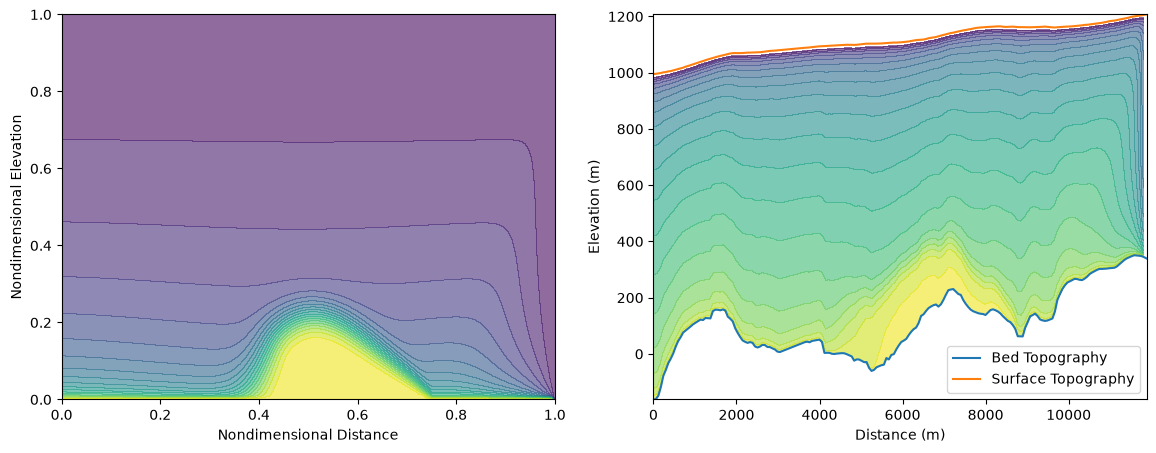

In [46]:
geometry_data_path = '../data/interpolated_bed_picks_20080722_02.csv'
geometry_data = pd.read_csv(geometry_data_path)

# transform simulated age field data to physical coordinate
def inverse_transform_geometry(X_grid, Z_grid, zs, zb, x_physical):
    """ inverse transform the nondimensional age field to physical coordinates using surface and bed topography. 

    Non-dimensional coordinates are defined as:
        x_tilde  = x / L
        zeta     = (z - b) / H          ∈ [0, 1]
    where L is the horizontal length scale, H is the ice thickness, b is the bed topography, and z is the vertical coordinate.
    We solve for physical coordinates (x, z) 
    
    Parameters
    ----------
    X_grid : 2D array
        Nondimensional x grid of the age field.
    Z_grid : 2D array
        Nondimensional z grid of the age field.
    zs : 1D array
        Surface topography.
    zb : 1D array
        Bed topography.
    x_physical: 1D array
        Physical x coordinates (usually just along flow distance)
    
    Returns
    -------
    X_phys : 2D array
        Physical x coordinates.
    Z_phys : 2D array
        Physical z coordinates.
    """
    # Get the number of grid points
    nx = X_grid.shape[1]
    nz = Z_grid.shape[0]

    # first interpolate zs and zb to the same grid resolution as X_grid and Z_grid
    zs = np.interp(np.linspace(0, 1, nx), np.linspace(0, 1, len(zs)), zs)
    zb = np.interp(np.linspace(0, 1, nx), np.linspace(0, 1, len(zb)), zb)

    L = np.max(x_physical) - np.min(x_physical)  

    # Initialize physical coordinates
    X_phys = np.zeros_like(X_grid)
    Z_phys = np.zeros_like(Z_grid)

    # Loop over each x position to compute physical coordinates
    for i in range(nx):
        H = zs[i] - zb[i]  # Ice thickness at this x position
        X_phys[:, i] = X_grid[:, i] * L  # Scale x by horizontal length scale
        Z_phys[:, i] = Z_grid[:, i] * H + zb[i]  # Scale z by ice thickness and add bed topography

    return X_phys, Z_phys

X_phys, Z_phys = inverse_transform_geometry(model_pert.XX, model_pert.ZZ, 
                    geometry_data['surface'].values, geometry_data['bottom'].values,
                    geometry_data['Dist'].values)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
# in nondimensional space
plt.contourf(np.fliplr(model_pert.XX), model_pert.ZZ, model_pert.X, levels=20, cmap='viridis', alpha=0.6)
plt.xlabel('Nondimensional Distance')
plt.ylabel('Nondimensional Elevation')

plt.subplot(1,2,2)
# plt.plot(np.fliplr(geometry_data['Dist'].values.reshape(1, -1)), np.fliplr(geometry_data['bottom'].values.reshape(1, -1)), label='Bed Topography')
# plt.plot(np.fliplr(geometry_data['Dist'].values.reshape(1, -1)), np.fliplr(geometry_data['surface'].values.reshape(1, -1)), label='Surface Topography')
plt.plot(np.fliplr(geometry_data['Dist'].values.reshape(1, -1)).ravel(), 
         geometry_data['bottom'].values.reshape(1, -1).ravel(), label='Bed Topography')
plt.plot(np.fliplr(geometry_data['Dist'].values.reshape(1, -1)).ravel(), 
         geometry_data['surface'].values.reshape(1, -1).ravel(), label='Surface Topography')
plt.contourf(np.fliplr(X_phys), Z_phys, np.log10(model_pert.X), levels=20, cmap='viridis', alpha=0.6)
plt.xlabel('Distance (m)')
plt.ylabel('Elevation (m)')
# legend at the corner
plt.legend(loc='lower right')
plt.show()



### Animation

  Animating 21 frames  (t = 0.00 → 8.00 nondim)
  Baseline CFL dt_macro = 0.00404  (u_max=0.400, w_max=1.0000)
  Saving animation → age_anomaly_evolution.gif  (21 frames @ 5 fps)...


Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f534' [U+1f5

  Saved.


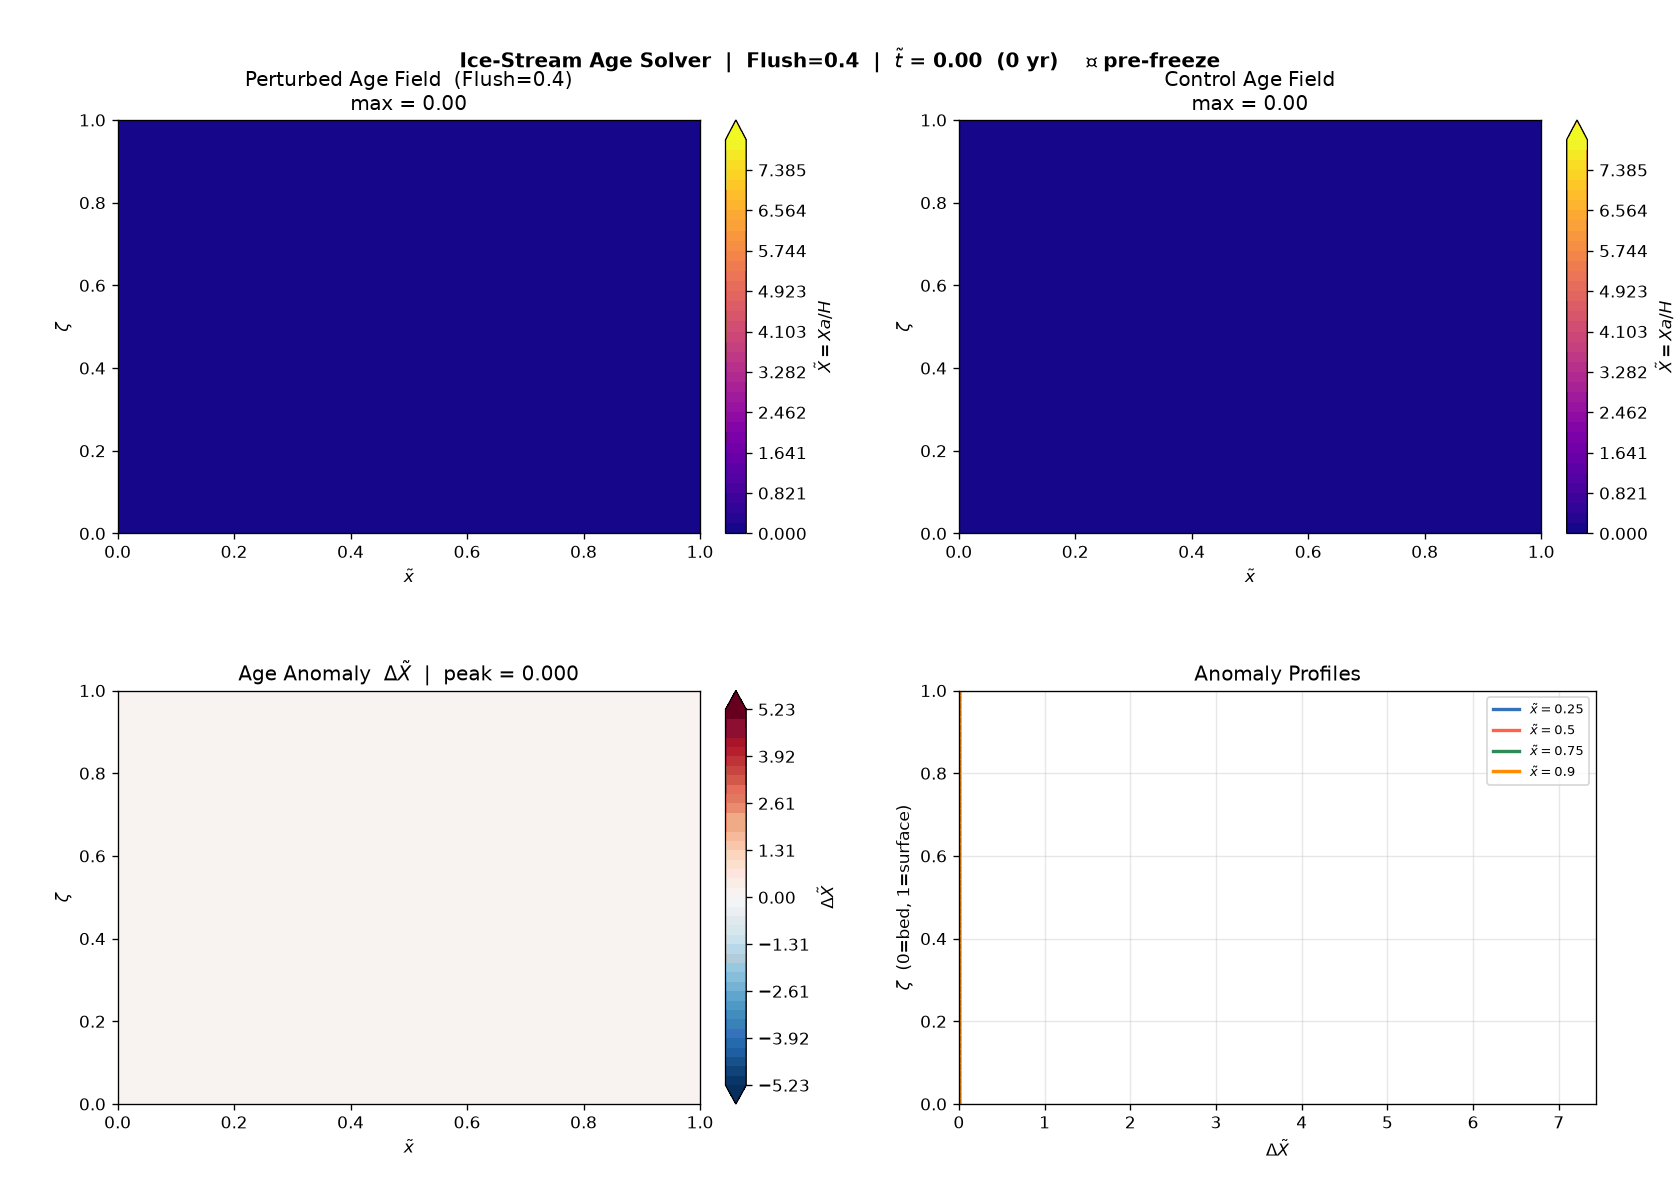

Font 'default' does not have a glyph for '\U0001f534' [U+1f534], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2b1b' [U+2b1b], substituting with a dummy symbol.


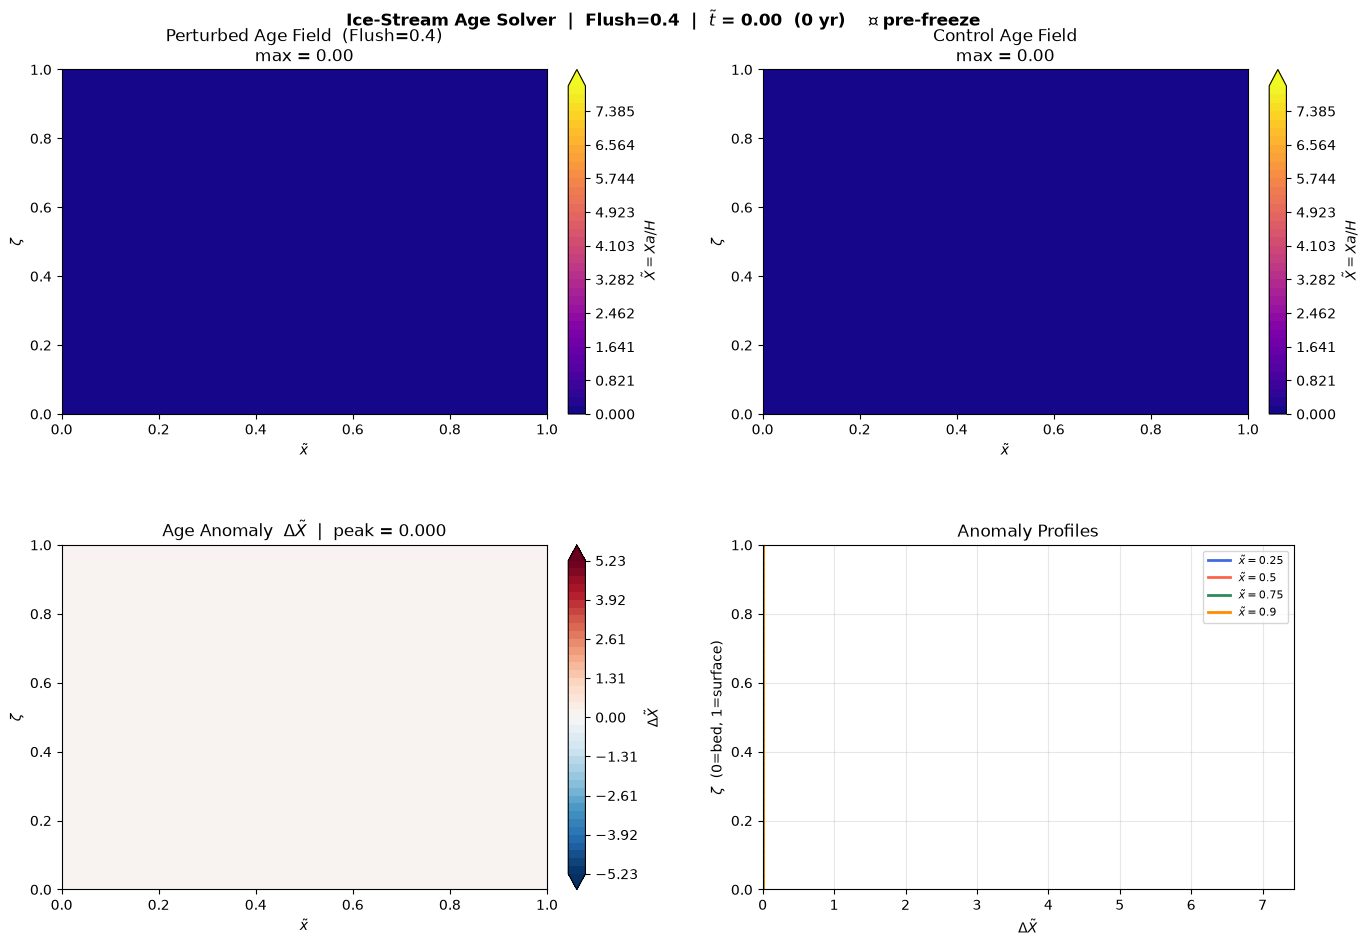

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 4: Animation — Age Anomaly + Velocity Quiver over time
# ─────────────────────────────────────────────────────────────────────────────
# Requires snapshots from BOTH runs at matching times.
# snapshot_interval=500 gives ~16 frames for N_RES=8 — smooth enough.
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

# ── Sanity check: both models must have same number of snapshots ──────────────
n_frames = min(len(model_ctrl.age_snapshots), len(model_pert.age_snapshots))
times    = model_pert.time_series[:n_frames]
print(f"  Animating {n_frames} frames  "
      f"(t = {times[0]:.2f} → {times[-1]:.2f} nondim)")

# ── Pre-compute anomaly stack and global colour limits ────────────────────────
dX_stack = np.array([
    model_pert.age_snapshots[i] - model_ctrl.age_snapshots[i]
    for i in range(n_frames)
])                                                        # (n_frames, nz, nx)

# Symmetric colour scale fixed to the global 98th percentile
vabs_global = np.percentile(np.abs(dX_stack), 98)
levels_dX   = np.linspace(-vabs_global, vabs_global, 41)

# Age field colour scale (perturbed, 98th pct of final frame)
vmax_age  = np.percentile(model_pert.age_snapshots[-1], 98)
levels_age = np.linspace(0, vmax_age, 40)

# Quiver subsample
qskip = (slice(None, None, 8), slice(None, None, 10))

# ── Build velocity field for each frame ──────────────────────────────────────
# Rebuild w_basal at each snapshot time so quiver reflects the actual
# velocity that was active during that interval.
def wb_at(t):
    """Scalar basal velocity active at nondim time t (matches localized_freeze_on)."""
    if T_ON <= t < T_OFF:
        wb = np.zeros(150)
        x  = np.linspace(0, 1, 150)
        wb[(x >= 0.3) & (x <= 0.7)] = W_FREEZE
        return wb
    return 0.0

# Cache (u, w) snapshots — cheap since _build_velocity is fast
vel_snapshots = []
_tmp = SigmaAgeModel(**COMMON)   # throwaway model just for velocity rebuilds
for t in times:
    _tmp._build_velocity(w_basal=wb_at(t))
    vel_snapshots.append((_tmp.u.copy(), _tmp.w.copy()))

# ── Figure layout ─────────────────────────────────────────────────────────────
fig_anim = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(
    2, 2,
    figure=fig_anim,
    hspace=0.38, wspace=0.32,
    left=0.07, right=0.95, top=0.90, bottom=0.08
)

ax_age  = fig_anim.add_subplot(gs[0, 0])   # perturbed age field
ax_ctrl = fig_anim.add_subplot(gs[0, 1])   # control age field
ax_dX   = fig_anim.add_subplot(gs[1, 0])   # anomaly ΔX
ax_prof = fig_anim.add_subplot(gs[1, 1])   # anomaly depth profiles

XX, ZZ = model_ctrl.XX, model_ctrl.ZZ
x_nd   = model_ctrl.x
zeta   = model_ctrl.zeta

# ── Initial draw — all artists we will update each frame ─────────────────────

# --- Top-left: perturbed age field + quiver ----------------------------------
cf_age = ax_age.contourf(XX, ZZ, model_pert.age_snapshots[0],
                         levels=levels_age, cmap='plasma', extend='max')
cb_age = fig_anim.colorbar(cf_age, ax=ax_age, label=r'$\tilde{X} = Xa/H$',
                            fraction=0.046, pad=0.04)
u0, w0 = vel_snapshots[0]
qv_age = ax_age.quiver(
    XX[qskip], ZZ[qskip],
    u0[qskip], w0[qskip] * 3,
    color='white', scale=30, width=0.003, alpha=0.75
)
ax_age.set_xlim(0, 1); ax_age.set_ylim(0, 1)
ax_age.set_xlabel(r'$\tilde{x}$'); ax_age.set_ylabel(r'$\zeta$')
ttl_age = ax_age.set_title('')

# Freeze-on region indicator bar along the bottom
freeze_bar_age = ax_age.axhspan(0, 0.02, xmin=0.3, xmax=0.7,
                                 color='cyan', alpha=0.0)   # toggled on/off

# --- Top-right: control age field --------------------------------------------
cf_ctrl = ax_ctrl.contourf(XX, ZZ, model_ctrl.age_snapshots[0],
                            levels=levels_age, cmap='plasma', extend='max')
fig_anim.colorbar(cf_ctrl, ax=ax_ctrl, label=r'$\tilde{X} = Xa/H$',
                  fraction=0.046, pad=0.04)
ax_ctrl.set_xlim(0, 1); ax_ctrl.set_ylim(0, 1)
ax_ctrl.set_xlabel(r'$\tilde{x}$'); ax_ctrl.set_ylabel(r'$\zeta$')
ttl_ctrl = ax_ctrl.set_title('')

# --- Bottom-left: anomaly ΔX -------------------------------------------------
cf_dX = ax_dX.contourf(XX, ZZ, dX_stack[0],
                        levels=levels_dX, cmap='RdBu_r', extend='both')
cb_dX = fig_anim.colorbar(cf_dX, ax=ax_dX, label=r'$\Delta\tilde{X}$',
                           fraction=0.046, pad=0.04)
cs_zero = ax_dX.contour(XX, ZZ, dX_stack[0],
                         levels=[0], colors='k', linewidths=1.0)
u0, w0 = vel_snapshots[0]
qv_dX  = ax_dX.quiver(
    XX[qskip], ZZ[qskip],
    u0[qskip], w0[qskip] * 3,
    color='k', scale=30, width=0.003, alpha=0.6
)
ax_dX.set_xlim(0, 1); ax_dX.set_ylim(0, 1)
ax_dX.set_xlabel(r'$\tilde{x}$'); ax_dX.set_ylabel(r'$\zeta$')
ttl_dX = ax_dX.set_title('')

# Freeze-on active label
freeze_txt = ax_dX.text(
    0.50, 0.94, '', transform=ax_dX.transAxes,
    ha='center', va='top', fontsize=9,
    color='white', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='crimson', alpha=0.0)
)

# --- Bottom-right: anomaly depth profiles ------------------------------------
prof_cols = ['royalblue', 'tomato', 'seagreen', 'darkorange']
prof_pos  = [0.25, 0.50, 0.75, 0.90]
prof_lines = []
for col, pos in zip(prof_cols, prof_pos):
    ix = int(pos * model_ctrl.nx)
    ln, = ax_prof.plot(dX_stack[0][:, ix], zeta, color=col, lw=2,
                       label=fr'$\tilde{{x}}={pos}$')
    prof_lines.append((ln, ix))

ax_prof.axvline(0, color='k', lw=0.8, ls='--')
ax_prof.set_xlabel(r'$\Delta\tilde{X}$')
ax_prof.set_ylabel(r'$\zeta$  (0=bed, 1=surface)')
ax_prof.set_title('Anomaly Profiles')
ax_prof.legend(fontsize=8, loc='upper right')
ax_prof.grid(True, alpha=0.3)
ax_prof.set_ylim(0, 1)
# x-axis limits: fixed to global range
prof_xlim = (dX_stack.min() * 1.05, dX_stack.max() * 1.05)
ax_prof.set_xlim(prof_xlim)

# Suptitle
suptitle = fig_anim.suptitle('', fontsize=12, fontweight='bold', y=0.96)
def update(frame):
    t      = times[frame]
    dX     = dX_stack[frame]
    X_pert = model_pert.age_snapshots[frame]
    X_ctrl = model_ctrl.age_snapshots[frame]
    u, w   = vel_snapshots[frame]
    active = T_ON <= t < T_OFF

    # ── Suptitle ──────────────────────────────────────────────────────────────
    phase = "🔴 FREEZE-ON ACTIVE" if active else (
            "⬛ pre-freeze" if t < T_ON else "🔵 post-freeze")
    suptitle.set_text(
        f"Ice-Stream Age Solver  |  Flush={FLUSH}  |  "
        fr"$\tilde{{t}}$ = {t:.2f}  ({t * t_scale:.0f} yr)    {phase}"
    )

    # ── Helper: remove only contourf/contour collections, leave quivers ───────
    def clear_contours(ax):
        """Remove ContourSet collections but preserve Quiver artists."""
        to_remove = [
            c for c in ax.collections
            if not isinstance(c, plt.matplotlib.quiver.Quiver)
        ]
        for c in to_remove:
            c.remove()

    # ── Top-left: perturbed age field ─────────────────────────────────────────
    clear_contours(ax_age)
    ax_age.contourf(XX, ZZ, X_pert, levels=levels_age,
                    cmap='plasma', extend='max')
    qv_age.set_UVC(u[qskip], w[qskip] * 3)          # update in-place ✓
    freeze_bar_age.set_alpha(0.25 if active else 0.0)
    ttl_age.set_text(
        f'Perturbed Age Field  (Flush={FLUSH})\n'
        f'max = {X_pert.max():.2f}'
    )

    # ── Top-right: control age field ──────────────────────────────────────────
    clear_contours(ax_ctrl)
    ax_ctrl.contourf(XX, ZZ, X_ctrl, levels=levels_age,
                     cmap='plasma', extend='max')
    ttl_ctrl.set_text(
        f'Control Age Field\n'
        f'max = {X_ctrl.max():.2f}'
    )

    # ── Bottom-left: anomaly + quiver ─────────────────────────────────────────
    clear_contours(ax_dX)
    ax_dX.contourf(XX, ZZ, dX, levels=levels_dX,
                   cmap='RdBu_r', extend='both')
    ax_dX.contour(XX, ZZ, dX, levels=[0],
                  colors='k', linewidths=1.0)
    qv_dX.set_UVC(u[qskip], w[qskip] * 3)           # update in-place ✓
    ttl_dX.set_text(
        fr'Age Anomaly  $\Delta\tilde{{X}}$  |  '
        f'peak = {np.abs(dX).max():.3f}'
    )
    freeze_txt.set_text("⬆ freeze-on active" if active else "")
    freeze_txt.get_bbox_patch().set_alpha(0.75 if active else 0.0)

    # ── Bottom-right: anomaly depth profiles ──────────────────────────────────
    for ln, ix in prof_lines:
        ln.set_xdata(dX[:, ix])

    return []


# ── Render ────────────────────────────────────────────────────────────────────
anim = FuncAnimation(
    fig_anim, update,
    frames=n_frames,
    interval=200,      # ms between frames in display
    blit=False,
    repeat=True,
)

# ── Save as GIF ───────────────────────────────────────────────────────────────
gif_path = '../fig/age_anomaly_evolution.gif'
writer   = PillowWriter(fps=5)
print(f"  Saving animation → {gif_path}  ({n_frames} frames @ 5 fps)...")
anim.save(gif_path, writer=writer, dpi=120)
print(f"  Saved.")

# ── Display inline in Jupyter ─────────────────────────────────────────────────
from IPython.display import Image, display
display(Image(filename=gif_path))


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from itertools import product
from scipy.ndimage import label
import time

# ─────────────────────────────────────────────────────────────────────────────
# Physical scales
# ─────────────────────────────────────────────────────────────────────────────
PHYS = dict(u_s_myr=100.0, H_m=1000.0, a_myr=0.5, L_m=35_000.)
t_scale = PHYS['H_m'] / PHYS['a_myr']   # yr per nondim time unit
x_scale = PHYS['L_m']                    # m per nondim x
z_scale = PHYS['H_m']                    # m per nondim zeta


# ─────────────────────────────────────────────────────────────────────────────
# Blob extractor (no plot, fast)
# ─────────────────────────────────────────────────────────────────────────────
def extract_blob_geometry_fast(ctrl, pert, threshold_frac=0.15):
    """
    Returns (length_nd, height_nd) of the dominant positive anomaly blob.
    Returns (np.nan, np.nan) if no blob is found.
    """
    dX   = pert.X - ctrl.X
    vabs = np.abs(dX).max()
    if vabs < 1e-10:
        return np.nan, np.nan

    mask = dX > threshold_frac * vabs
    labeled, n = label(mask)
    if n == 0:
        return np.nan, np.nan

    # Largest connected blob
    sizes    = [(labeled == i).sum() for i in range(1, n + 1)]
    dominant = np.argmax(sizes) + 1
    blob     = (labeled == dominant)

    zeta_idx, x_idx = np.where(blob)
    length_nd = ctrl.x[x_idx.max()]    - ctrl.x[x_idx.min()]
    height_nd = ctrl.zeta[zeta_idx.max()] - ctrl.zeta[zeta_idx.min()]
    return length_nd, height_nd


# ─────────────────────────────────────────────────────────────────────────────
# Sweep grid  — keep it coarse enough to finish in ~10–15 min
# ─────────────────────────────────────────────────────────────────────────────
# Flushing number: push into the range where length drops to ~10 km
FLUSH_VALS  = np.array([1.0, 2.0, 4.0])

# Freeze-on rate: need much higher to reach 500 m blob height
# In nondim: w_freeze = rate / a_myr = rate / 0.5
# 5→10→20→40→80→150 m/yr  →  w_freeze = 10, 20, 40, 80, 160, 300
W_VALS_PHYS = np.array([5., 10., 20., 40., 80., 150.])   # m/yr
W_VALS      = W_VALS_PHYS / PHYS['a_myr']                 # nondim

# Duration: concentrate on 500–6000 yr where height is still rising
DUR_VALS_YR = np.array([500., 1000., 2000., 3000., 4500., 6000.])
DUR_VALS    = DUR_VALS_YR / t_scale                        # nondim

T_ON  = 1.0
N_RES = 12    # bump up slightly so high-F blobs have time to advect through

print("New sweep grid:")
print(f"  FLUSH_VALS  = {FLUSH_VALS}")
print(f"  W_VALS      = {W_VALS}  (nondim)")
print(f"  W_VALS_PHYS = {W_VALS_PHYS} m/yr")
print(f"  DUR_VALS    = {DUR_VALS}  (nondim)")
print(f"  DUR_VALS_YR = {DUR_VALS_YR} yr")
print(f"  Total runs  = {len(FLUSH_VALS) * (1 + len(W_VALS)*len(DUR_VALS)) * 2} "
      f"(shared ctrl per F)")



COMMON = dict(nx=150, nz=100, bed_amp=0.10, cfl_safety=0.4)

nW   = len(W_VALS)
nD   = len(DUR_VALS)
nF   = len(FLUSH_VALS)

# Storage: [flush, w, duration]
length_grid = np.full((nF, nW, nD), np.nan)
height_grid = np.full((nF, nW, nD), np.nan)

total_runs = nF * nW * nD * 2   # *2 for ctrl+pert pair each
print(f"  Total forward runs: {total_runs}  "
      f"({nF} flush × {nW} w_freeze × {nD} durations × 2)")
print(f"  Estimated time: ~{total_runs * 15 / 60:.0f} min  "
      f"(assuming ~15 s per run)\n")

t_start = time.time()
run_count = 0

for fi, flush in enumerate(FLUSH_VALS):
    # Control run is shared across all (w, dur) for a given flush
    print(f"  ── Flush = {flush:.3f}  ({fi+1}/{nF}) ──────────────────────")
    ctrl = SigmaAgeModel(**COMMON, Flush=flush)
    ctrl.run(n_residence_times=N_RES,
             basal_perturbation=None,
             verbose=False)
    run_count += 1

    for wi, w_freeze in enumerate(W_VALS):
        for di, dur in enumerate(DUR_VALS):
            t_off = T_ON + dur

            # def perturb(t, _w=w_freeze, _ton=T_ON, _toff=t_off):
            #     return _w if _ton <= t < _toff else 0.0

            pert = SigmaAgeModel(**COMMON, Flush=flush)
            pert.run(n_residence_times=N_RES,
                     basal_perturbation=localized_freeze_on,
                     verbose=False)
            run_count += 1

            l_nd, h_nd = extract_blob_geometry_fast(ctrl, pert)
            length_grid[fi, wi, di] = l_nd
            height_grid[fi, wi, di] = h_nd

            elapsed = time.time() - t_start
            eta     = elapsed / run_count * (total_runs - run_count)
            print(f"    Flush={flush:.2f}  w={w_freeze:5.1f}  "
                  f"dur={dur:.1f}  →  "
                  f"L={l_nd*x_scale/1e3:5.2f} km  "
                  f"H={h_nd*z_scale:5.0f} m  "
                  f"[{run_count}/{total_runs}  ETA {eta/60:.1f} min]")

print(f"\n  Sweep complete in {(time.time()-t_start)/60:.1f} min")



New sweep grid:
  FLUSH_VALS  = [1. 2. 4.]
  W_VALS      = [ 10.  20.  40.  80. 160. 300.]  (nondim)
  W_VALS_PHYS = [  5.  10.  20.  40.  80. 150.] m/yr
  DUR_VALS    = [0.25 0.5  1.   1.5  2.25 3.  ]  (nondim)
  DUR_VALS_YR = [ 500. 1000. 2000. 3000. 4500. 6000.] yr
  Total runs  = 222 (shared ctrl per F)
  Total forward runs: 216  (3 flush × 6 w_freeze × 6 durations × 2)
  Estimated time: ~54 min  (assuming ~15 s per run)

  ── Flush = 1.000  (1/3) ──────────────────────
  Baseline CFL dt_macro = 0.00268  (u_max=1.000, w_max=1.0000)
  Running 4469 macro-steps  (t_total=12.0 residence times, perturbation=OFF)
  Done.  Max sub-steps used in any macro-step: 1  (dt_macro=0.00268)
  Baseline CFL dt_macro = 0.00268  (u_max=1.000, w_max=1.0000)
  Running 4469 macro-steps  (t_total=12.0 residence times, perturbation=ON)
  Done.  Max sub-steps used in any macro-step: 2  (dt_macro=0.00268)
    Flush=1.00  w= 10.0  dur=0.2  →  L= 7.05 km  H=   40 m  [2/216  ETA 7.2 min]
  Baseline CFL dt_macro

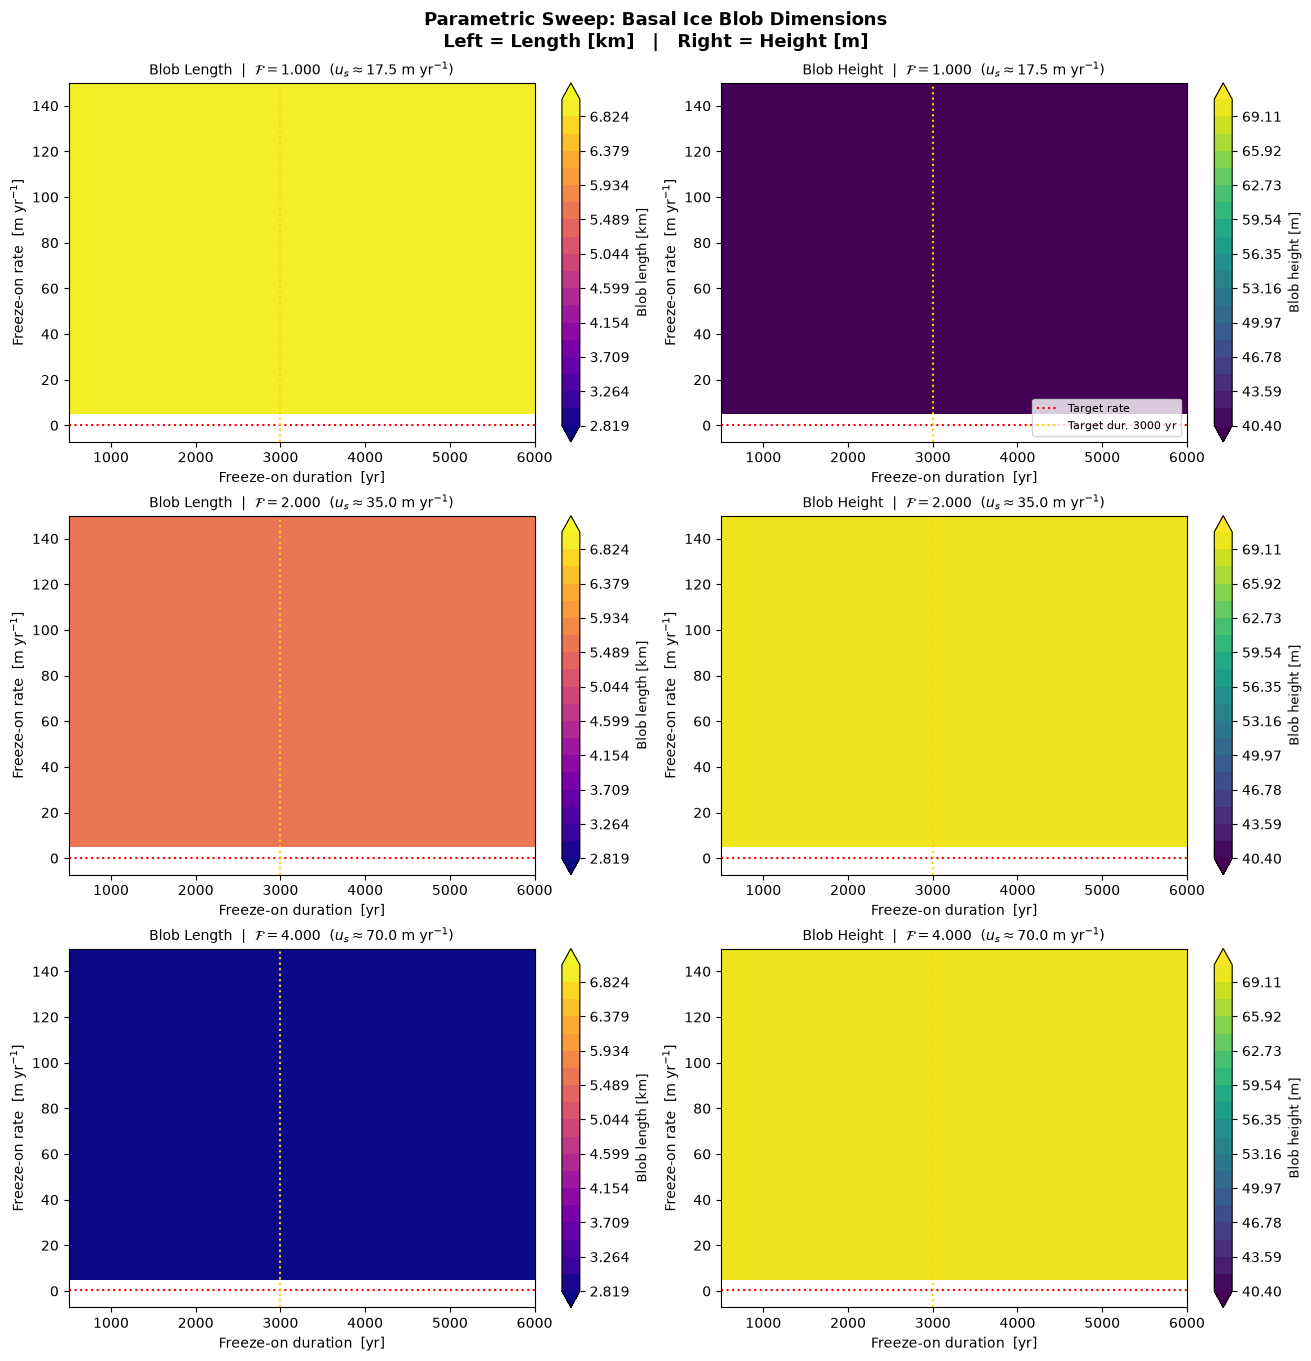

  Figure saved → parametric_sweep.png


In [48]:

# ─────────────────────────────────────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────────────────────────────────────
# Convert to physical for axis labels
W_phys   = W_VALS   * PHYS['a_myr']                  # m/yr freeze-on rate
D_phys   = DUR_VALS * t_scale                         # yr duration
L_phys   = length_grid * x_scale / 1e3               # km
H_phys   = height_grid * z_scale                     # m

WW, DD = np.meshgrid(W_phys, D_phys, indexing='ij')  # (nW, nD)

fig, axes = plt.subplots(
    nF, 2,
    figsize=(13, 4.5 * nF),
    constrained_layout=True,
)
fig.suptitle(
    'Parametric Sweep: Basal Ice Blob Dimensions\n'
    r'Left = Length [km]   |   Right = Height [m]',
    fontsize=13, fontweight='bold'
)

cmap_L = 'plasma'
cmap_H = 'viridis'

for fi, flush in enumerate(FLUSH_VALS):
    Ldata = L_phys[fi]   # (nW, nD)
    Hdata = H_phys[fi]   # (nW, nD)

    flush_u = flush * PHYS['a_myr'] * PHYS['L_m'] / PHYS['H_m']
    subtitle = (fr'$\mathcal{{F}}={flush:.3f}$  '
                fr'($u_s \approx {flush_u:.1f}$ m yr$^{{-1}}$)')

    # ── Length panel ─────────────────────────────────────────────────────────
    ax = axes[fi, 0]
    vmin_L, vmax_L = np.nanpercentile(L_phys, [2, 98])
    levels_L = np.linspace(vmin_L, vmax_L, 20)
    cf = ax.contourf(DD, WW, Ldata,
                     levels=levels_L, cmap=cmap_L, extend='both')
    cs = ax.contour(DD, WW, Ldata,
                    levels=levels_L[::3], colors='white',
                    linewidths=0.7, alpha=0.6)
    ax.clabel(cs, fmt='%.1f km', fontsize=7, colors='white')
    cb = fig.colorbar(cf, ax=ax, pad=0.02)
    cb.set_label('Blob length [km]', fontsize=9)

    # Mark NaN region (no blob detected)
    nan_mask = np.isnan(Ldata)
    if nan_mask.any():
        ax.contourf(DD, WW, nan_mask.astype(float),
                    levels=[0.5, 1.5], colors=['lightgray'], alpha=0.5)
        ax.contour(DD, WW, nan_mask.astype(float),
                   levels=[0.5], colors=['gray'], linewidths=1.2,
                   linestyles='--')

    ax.set_xlabel(r'Freeze-on duration  [yr]', fontsize=10)
    ax.set_ylabel(r'Freeze-on rate  [m yr$^{-1}$]', fontsize=10)
    ax.set_title(f'Blob Length  |  {subtitle}', fontsize=10)

    # ── Height panel ─────────────────────────────────────────────────────────
    ax = axes[fi, 1]
    vmin_H, vmax_H = np.nanpercentile(H_phys, [2, 98])
    levels_H = np.linspace(vmin_H, vmax_H, 20)
    cf = ax.contourf(DD, WW, Hdata,
                     levels=levels_H, cmap=cmap_H, extend='both')
    cs = ax.contour(DD, WW, Hdata,
                    levels=levels_H[::3], colors='white',
                    linewidths=0.7, alpha=0.6)
    ax.clabel(cs, fmt='%.0f m', fontsize=7, colors='white')
    cb = fig.colorbar(cf, ax=ax, pad=0.02)
    cb.set_label('Blob height [m]', fontsize=9)

    if nan_mask.any():
        ax.contourf(DD, WW, nan_mask.astype(float),
                    levels=[0.5, 1.5], colors=['lightgray'], alpha=0.5)
        ax.contour(DD, WW, nan_mask.astype(float),
                   levels=[0.5], colors=['gray'], linewidths=1.2,
                   linestyles='--')

    ax.set_xlabel(r'Freeze-on duration  [yr]', fontsize=10)
    ax.set_ylabel(r'Freeze-on rate  [m yr$^{-1}$]', fontsize=10)
    ax.set_title(f'Blob Height  |  {subtitle}', fontsize=10)

    # ── Target overlay on both panels ────────────────────────────────────────
    for col in [0, 1]:
        axt = axes[fi, col]
        axt.axhline(0.5 * PHYS['a_myr'], color='red', lw=1.5,
                    ls=':', label='Target rate')
        axt.axvline(TARGET_DUR_YR := 3000., color='gold', lw=1.5,
                    ls=':', label=f'Target dur. {TARGET_DUR_YR:.0f} yr')
        if fi == 0 and col == 1:
            axt.legend(fontsize=8, loc='lower right')

plt.savefig('parametric_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Figure saved → parametric_sweep.png")